# Optimization — Minimum Chargers per Location (LP / Simplex)

Replaces the regression approach with a **mixed-integer linear program** solved by SciPy's HiGHS / simplex engine (`scipy.optimize.milp`). The competition asks for the *minimum* number of chargers that covers 2027 demand — that is an optimisation objective, so we optimise it directly.

**Decision variable**
- `x_j ∈ ℤ≥1` — number of 150 kW chargers at shortlisted location *j*.

**Objective**
- **Minimise** `Σ x_j` — total chargers across the network.

**Constraints** (all derived from documented assumptions)
1. Demand coverage — each location handles its estimated 2027 daily sessions.
2. Grid capacity — total instantaneous power at a location cannot exceed local grid headroom.
3. Minimum presence — every shortlisted location gets at least one charger (`x_j ≥ 1`).

Output schema (`charger_counts.csv`) is identical to the regression version, so `Map.ipynb` and any downstream File 2 / File 3 generator keep working unchanged.

---
## 1 · Setup

In [18]:
import numpy as np
import pandas as pd
from scipy.optimize import milp, LinearConstraint, Bounds

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

DATA_DIR = "C:/Users/vldma/Datathon/Datasets/Modelling datasets"

---
## 2 · Load inputs

- `optimal_locations_top.csv` — classification shortlist (segments predicted to need a station).
- Raw segment dataset — joined on `segment_id` to recover `length_m`, `road_total_length_m`, grid-capacity columns, and admin strings (if the shortlist lacks them).

In [19]:
shortlist = pd.read_csv(f"{DATA_DIR}/optimal_locations_top.csv")
print("shortlist columns:", list(shortlist.columns))
print("shortlist rows:   ", len(shortlist))

assert "segment_id" in shortlist.columns, (
    "optimal_locations_top.csv has no segment_id column — re-run FE.ipynb and "
    "Classification.ipynb so metadata columns are preserved."
)

raw = pd.read_csv(f"{DATA_DIR}/ev_charging_segment_ml_dataset.csv")
raw.columns = [c.lower().strip().replace(" ", "_") for c in raw.columns]

# Pull every column we need for constraints + output.
need = [
    "segment_id", "carretera", "comunidad_autonoma", "provincia",
    "length_m", "road_total_length_m", "road_n_stations",
    "road_centroid_lat", "road_centroid_lon",
    "grid_capacity_3nearest_mw", "grid_capacity_occupied_mw",
]
raw_subset = raw[[c for c in need if c in raw.columns]]

# Merge — shortlist columns take priority; raw fills gaps.
df = shortlist.merge(raw_subset, on="segment_id", how="left", suffixes=("", "_raw"))
# Coalesce metadata (prefer shortlist, fall back to raw)
for col in ["carretera", "comunidad_autonoma", "provincia", "road_centroid_lat", "road_centroid_lon"]:
    if col + "_raw" in df.columns:
        df[col] = df[col].fillna(df[col + "_raw"])
        df = df.drop(columns=[col + "_raw"])

df["length_m"] = df["length_m"].fillna(df["length_m"].median())
df["grid_capacity_3nearest_mw"] = df["grid_capacity_3nearest_mw"].fillna(0)
df["grid_capacity_occupied_mw"] = df["grid_capacity_occupied_mw"].fillna(0)

n = len(df)
print(f"\ncandidate locations after merge: {n}")
df.head()

shortlist columns: ['segment_id', 'carretera', 'comunidad_autonoma', 'provincia', 'municipio', 'road_centroid_lat', 'road_centroid_lon', 'prob_needs_station', 'predicted_needs_station', 'actual_is_underserved']
shortlist rows:    81

candidate locations after merge: 81


,segment_id,carretera,comunidad_autonoma,provincia,municipio,road_centroid_lat,road_centroid_lon,prob_needs_station,predicted_needs_station,actual_is_underserved,length_m,road_total_length_m,road_n_stations,grid_capacity_3nearest_mw,grid_capacity_occupied_mw
0,1025,N-401,08 - C.La Mancha,Ciudad Real,Puertollano,39.001170,-3.928287,0.991121,1,1,105831.682152,105831.682152,1,156.24,40.00
1,705,N-211,02 - Aragón,Teruel,Escucha,40.890687,-0.769281,0.990548,1,1,85368.770097,313548.143063,4,35.24,5.24
2,733,N-232A,02 - Aragón,Teruel,Alcañiz,41.166500,-0.267939,0.989595,1,1,1065.023700,37667.106532,4,228.02,5.51
3,734,N-232A,02 - Aragón,Teruel,Alcañiz,41.166500,-0.267939,0.989595,1,1,1114.805881,37667.106532,4,228.02,5.51
4,702,N-204,unknown,unknown,unknown,40.603296,-3.247541,0.989011,1,1,66730.985484,66730.985484,0,0.00,0.00


---
## 3 · Documented assumptions

Every constant below should be cited and justified in the Analytical Report.

| Constant | Value | Rationale / source |
|---|---|---|
| `CHARGER_KW` | 150 | Fixed by competition §11 |
| `EV_FLEET_2027` | 327 883 | Mandatory datos.gob.es Exercise 3 output |
| `DAILY_TRIPS_PER_EV` | 1.2 | Average daily trips (INE mobility survey order-of-magnitude) |
| `FRACTION_INTERURBAN` | 0.15 | Share of trips on autopistas / autovías / nacionales |
| `FRACTION_NEEDS_CHARGE` | 0.10 | Share of interurban trips long enough to need a top-up |
| `SESSION_MINUTES` | 30 | Typical fast-charge dwell time at 150 kW |
| `OPERATING_HOURS_PER_DAY` | 16 | Busy window; off-peak chargers sit idle |
| `UTILISATION` | 0.50 | Peak-to-average factor — a charger isn't used every slot |

Derived: `SESSIONS_PER_DAY_PER_CHARGER = (16 × 60 / 30) × 0.5 = 16 sessions/day/charger`.

Demand is distributed **proportionally to segment length** across the shortlisted network — documented simplification in lieu of real traffic counts.

In [20]:
CHARGER_KW = 150
EV_FLEET_2027 = 327_883
DAILY_TRIPS_PER_EV = 1.2
FRACTION_INTERURBAN = 0.15
FRACTION_NEEDS_CHARGE = 0.10
SESSION_MINUTES = 30
OPERATING_HOURS_PER_DAY = 16
UTILISATION = 0.50

SESSIONS_PER_DAY_PER_CHARGER = (OPERATING_HOURS_PER_DAY * 60 / SESSION_MINUTES) * UTILISATION
print(f"sessions / day / charger: {SESSIONS_PER_DAY_PER_CHARGER:.1f}")

total_daily_sessions_2027 = (
    EV_FLEET_2027
    * DAILY_TRIPS_PER_EV
    * FRACTION_INTERURBAN
    * FRACTION_NEEDS_CHARGE
)
print(f"total interurban fast-charge sessions / day (2027): {total_daily_sessions_2027:,.0f}")

sessions / day / charger: 16.0
total interurban fast-charge sessions / day (2027): 5,902


---
## 4 · Per-location demand & grid headroom

In [21]:
# Segment demand (daily sessions)
total_shortlist_length = df["length_m"].sum()
df["daily_sessions_demand"] = total_daily_sessions_2027 * (df["length_m"] / total_shortlist_length)

# Grid headroom in kW (= free capacity = 3-nearest aggregated - already occupied)
df["grid_headroom_kw"] = np.clip(
    (df["grid_capacity_3nearest_mw"] - df["grid_capacity_occupied_mw"]) * 1000.0,
    0, None,
)

# When grid headroom is 0 (or missing), we don't want to block the LP →
# treat "no grid data" as "no known constraint" (large effective cap).
NO_GRID_CAP_SENTINEL = 1e9
df["grid_cap_effective_kw"] = np.where(df["grid_headroom_kw"] > 0,
                                       df["grid_headroom_kw"],
                                       NO_GRID_CAP_SENTINEL)

df[["segment_id", "carretera", "length_m",
    "daily_sessions_demand", "grid_headroom_kw"]].describe()

,segment_id,length_m,daily_sessions_demand,grid_headroom_kw
count,81.000000,81.000000,81.000000,81.000000
mean,831.395062,43606.458948,72.862889,78824.444444
std,335.246539,53243.939179,88.966344,89967.341964
min,75.000000,15.635710,0.026126,0.000000
25%,705.000000,1542.498326,2.577391,7460.000000
50%,748.000000,5826.453958,9.735536,42910.000000
75%,1077.000000,74854.876033,125.076483,165580.000000
max,1480.000000,232827.166963,389.035487,222510.000000


### 4.5 The LP, written out

Let $J = \{1, \dots, n\}$ index the shortlisted candidate locations and let $x_j \in \mathbb{Z}_{\ge 1}$ be the number of 150 kW chargers installed at location $j$.

$$
\begin{aligned}
\text{minimise} \quad & \sum_{j \in J} x_j \\
\text{subject to} \quad & s \cdot x_j \;\ge\; d_j && \forall\, j \in J \quad \text{(daily-session demand coverage)} \\
& P \cdot x_j \;\le\; g_j && \forall\, j \in J \quad \text{(local grid headroom)} \\
& x_j \;\ge\; 1, \quad x_j \in \mathbb{Z} && \forall\, j \in J
\end{aligned}
$$

Where
- $s = \text{SESSIONS\_PER\_DAY\_PER\_CHARGER} = 16$ — sessions served per charger per day.
- $d_j$ — 2027 daily-session demand at location $j$ (proportional to segment length).
- $P = 150$ kW — fixed charger power (competition §11).
- $g_j$ — free grid capacity (kW) near location $j$ (or $\infty$ when no data is available).

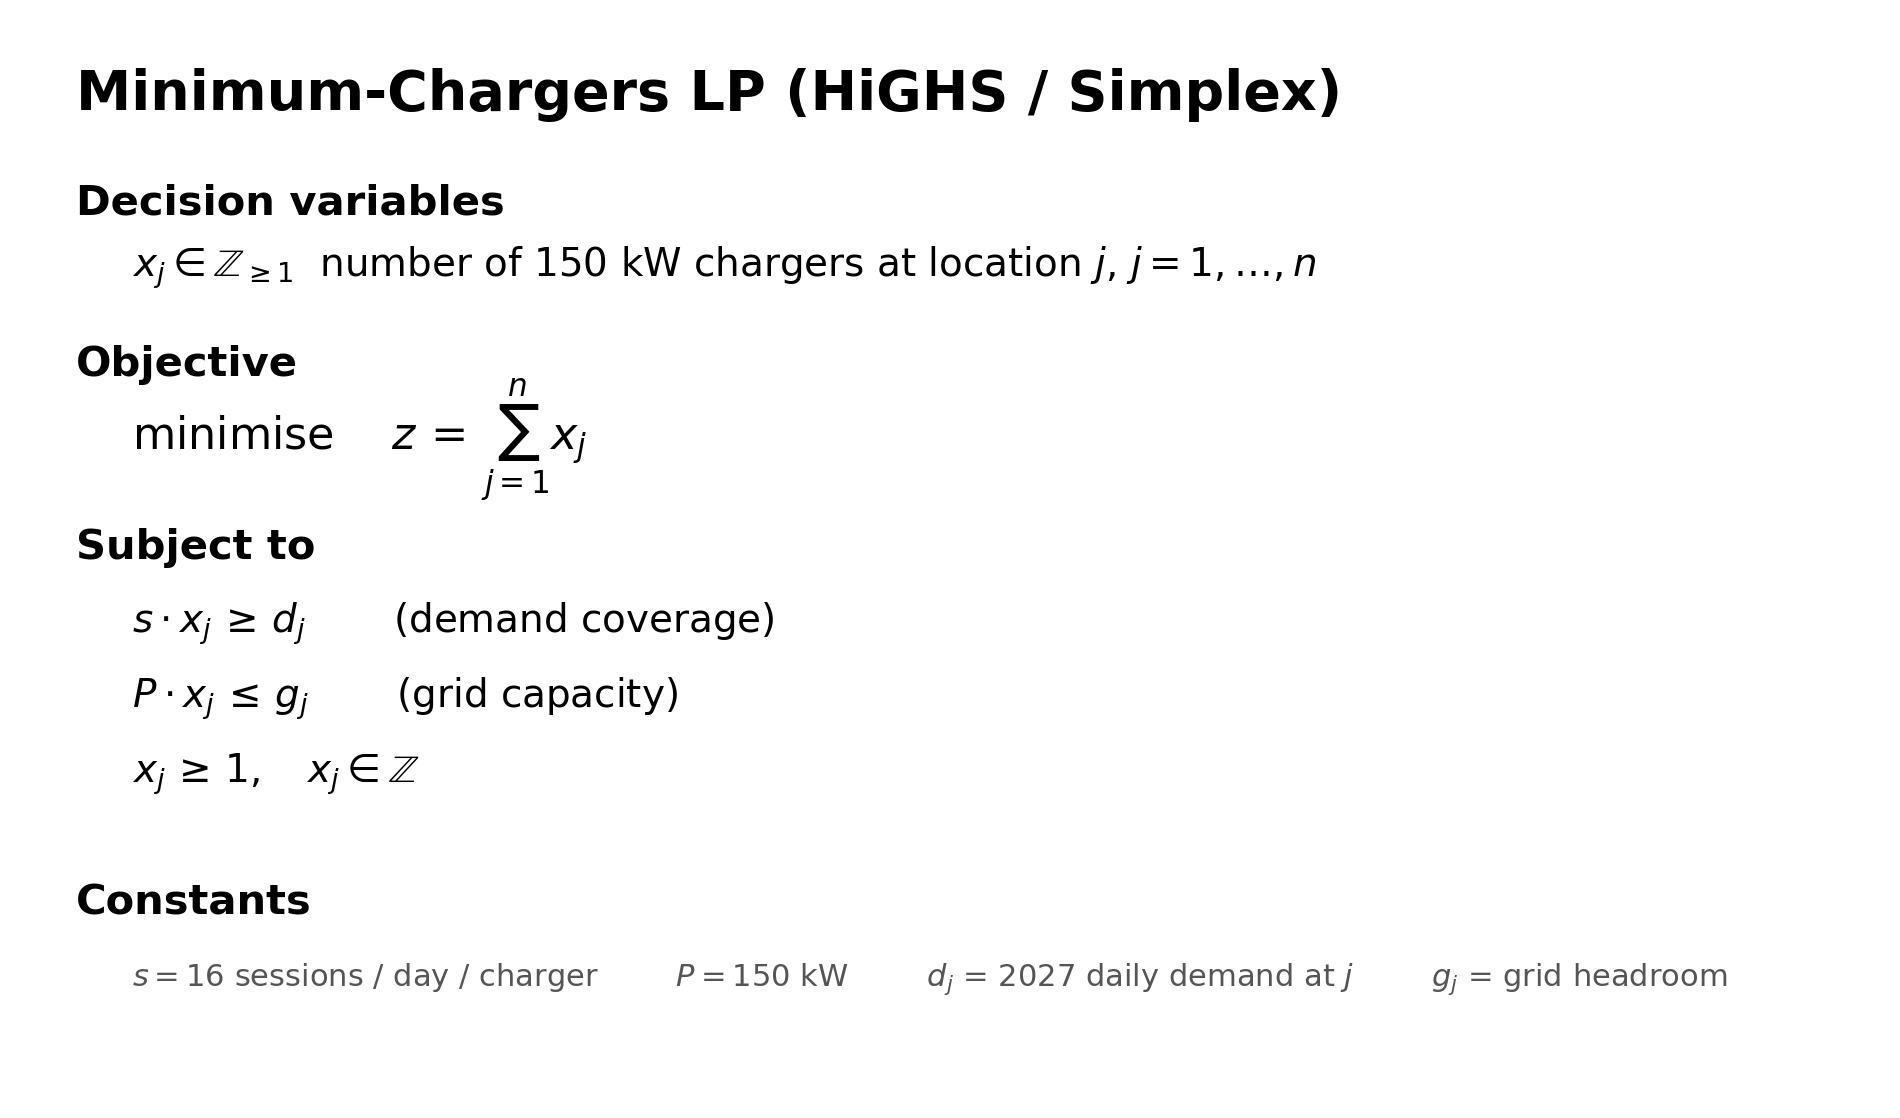

wrote C:/Users/vldma/Datathon/lp_formulation.png


In [22]:
# Render the abstract LP with one text call per line (mathtext-safe — no aligned envs).
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7), dpi=200)
ax.axis("off")
ax.set_xlim(0, 10); ax.set_ylim(0, 10)

ax.text(0.3, 9.3, "Minimum-Chargers LP (HiGHS / Simplex)",
        fontsize=20, fontweight="bold", va="center")

ax.text(0.3, 8.3, "Decision variables", fontsize=15, fontweight="bold", va="center")
ax.text(0.6, 7.7, r"$x_j \in \mathbb{Z}_{\geq 1}$  number of 150 kW chargers at location $j$, $j = 1, \ldots, n$",
        fontsize=14, va="center")

ax.text(0.3, 6.8, "Objective", fontsize=15, fontweight="bold", va="center")
ax.text(0.6, 6.1, r"minimise $\quad z \,=\, \sum_{j=1}^{n} x_j$",
        fontsize=16, va="center")

ax.text(0.3, 5.1, "Subject to", fontsize=15, fontweight="bold", va="center")
ax.text(0.6, 4.4, r"$s \cdot x_j \,\geq\, d_j \qquad$ (demand coverage)",
        fontsize=14, va="center")
ax.text(0.6, 3.7, r"$P \cdot x_j \,\leq\, g_j \qquad$ (grid capacity)",
        fontsize=14, va="center")
ax.text(0.6, 3.0, r"$x_j \,\geq\, 1, \quad x_j \in \mathbb{Z}$",
        fontsize=14, va="center")

ax.text(0.3, 1.8, "Constants", fontsize=15, fontweight="bold", va="center")
ax.text(0.6, 1.1,
        r"$s = 16$ sessions / day / charger  $\qquad P = 150$ kW  "
        r"$\qquad d_j$ = 2027 daily demand at $j$  $\qquad g_j$ = grid headroom",
        fontsize=11, va="center", color="#555")

PNG_PATH = "C:/Users/vldma/Datathon/lp_formulation.png"
fig.savefig(PNG_PATH, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"wrote {PNG_PATH}")

### 4.7 Hand-solvable Simplex example

The LP above has ~300 integer variables — you don't solve that by hand. Below is a **2-variable instance** with the same structural flavour (resource limits + a coupled budget), small enough to pivot through on paper. This mirrors the textbook *Wyndor-Glass* LP adapted to two EV-charger sites.

**Problem.** Two candidate locations on AP-7, $x_1$ = chargers at site 1, $x_2$ = chargers at site 2. Utility-per-charger reflects 2027 traffic: site 1 scores 3, site 2 scores 5. Site 1 has 4 installation slots; site 2 has 6 bays (2 chargers per bay ⇒ $2x_2 \le 12$). The shared grid budget spends 3 kW-units per site-1 charger and 2 kW-units per site-2 charger; the total budget is 18 units.

$$
\begin{array}{rll}
\text{maximise} & z = 3x_1 + 5x_2 & \text{(utility)} \\
\text{s.t.} & x_1 \;\le\; 4 & \text{(site-1 slots)} \\
            & 2x_2 \;\le\; 12 & \text{(site-2 bays)} \\
            & 3x_1 + 2x_2 \;\le\; 18 & \text{(grid budget)} \\
            & x_1, x_2 \ge 0 &
\end{array}
$$

Add slack variables $s_1, s_2, s_3 \ge 0$ so every constraint becomes an equality — that is the **standard form** Simplex wants:

$$
\begin{array}{l}
x_1 + s_1 = 4 \\
2x_2 + s_2 = 12 \\
3x_1 + 2x_2 + s_3 = 18 \\
z - 3x_1 - 5x_2 = 0
\end{array}
$$

The initial tableau is in §4.8. From there, pick the most-negative column in the $-z$ row, do the ratio test, pivot, repeat until all $-z$ entries are $\ge 0$. The optimum is at $x_1 = 2,\; x_2 = 6,\; z^* = 36$.

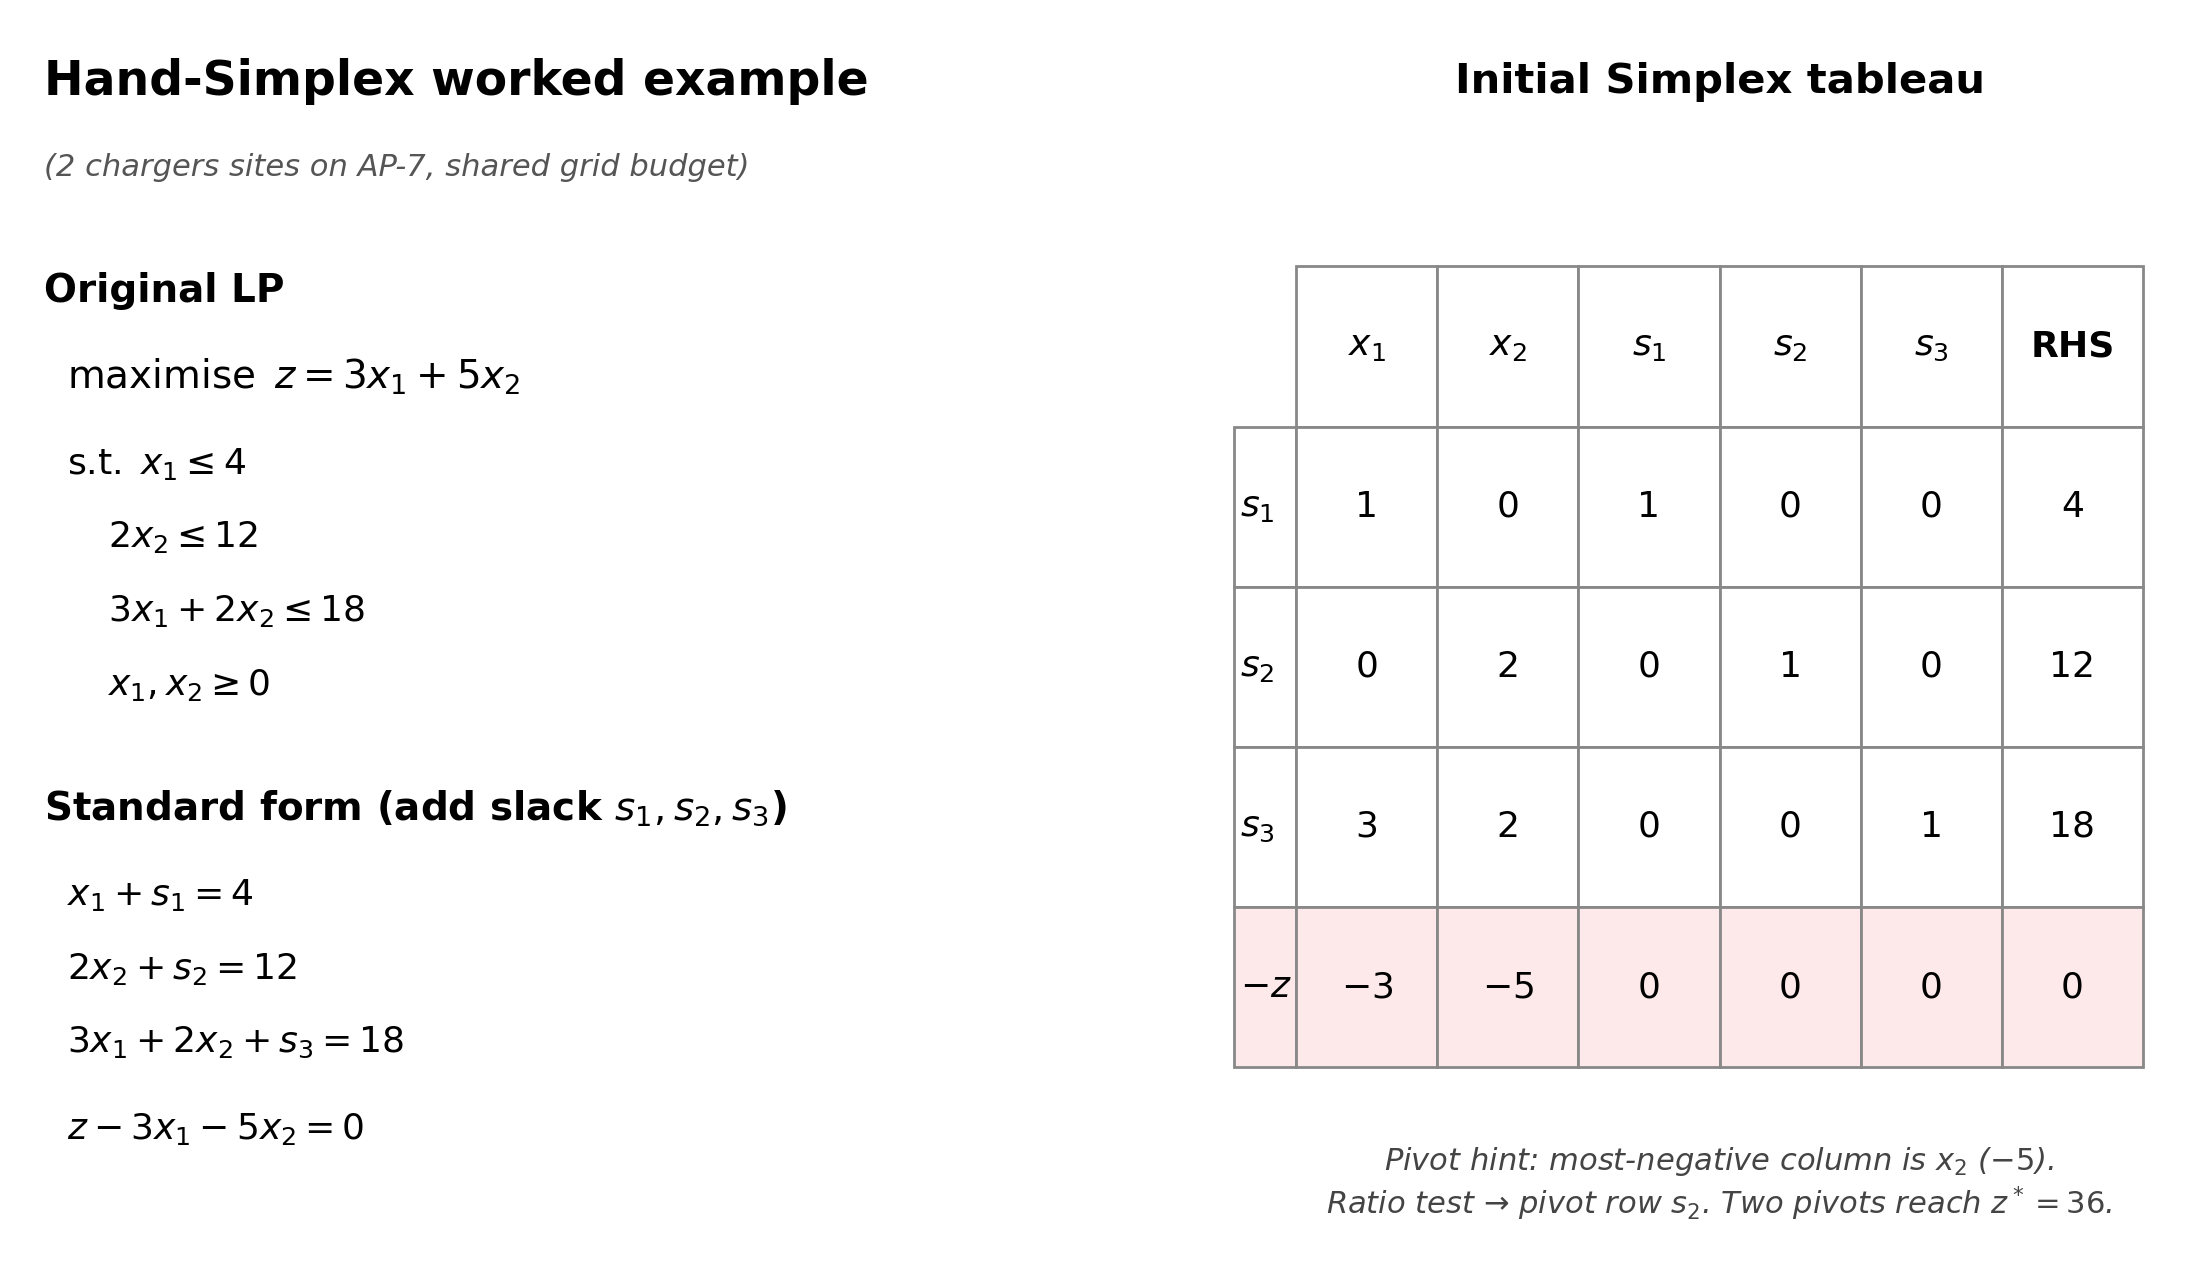

wrote C:/Users/vldma/Datathon/lp_hand_simplex.png


In [23]:
# Render the worked Simplex instance: LP statement + initial tableau.
# Left panel = problem, right panel = tableau (so both fit on one page).
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 8), dpi=200)
gs = fig.add_gridspec(1, 2, width_ratios=[5, 4], wspace=0.05)
ax_l = fig.add_subplot(gs[0, 0])
ax_r = fig.add_subplot(gs[0, 1])
for a in (ax_l, ax_r):
    a.axis("off"); a.set_xlim(0, 10); a.set_ylim(0, 10)

# ── Left panel: LP in standard form ──
ax_l.text(0.2, 9.5, "Hand-Simplex worked example", fontsize=17, fontweight="bold", va="center")
ax_l.text(0.2, 8.8, "(2 chargers sites on AP-7, shared grid budget)",
          fontsize=11, style="italic", color="#555", va="center")

ax_l.text(0.2, 7.8, "Original LP", fontsize=14, fontweight="bold", va="center")
ax_l.text(0.4, 7.1, r"maximise $\,z = 3x_1 + 5x_2$", fontsize=14, va="center")
ax_l.text(0.4, 6.4, r"s.t. $\,x_1 \leq 4$", fontsize=13, va="center")
ax_l.text(0.4, 5.8, r"$\quad\, 2x_2 \leq 12$", fontsize=13, va="center")
ax_l.text(0.4, 5.2, r"$\quad\, 3x_1 + 2x_2 \leq 18$", fontsize=13, va="center")
ax_l.text(0.4, 4.6, r"$\quad\, x_1, x_2 \geq 0$", fontsize=13, va="center")

ax_l.text(0.2, 3.6, "Standard form (add slack $s_1, s_2, s_3$)",
          fontsize=14, fontweight="bold", va="center")
ax_l.text(0.4, 2.9, r"$x_1 + s_1 = 4$", fontsize=13, va="center")
ax_l.text(0.4, 2.3, r"$2x_2 + s_2 = 12$", fontsize=13, va="center")
ax_l.text(0.4, 1.7, r"$3x_1 + 2x_2 + s_3 = 18$", fontsize=13, va="center")
ax_l.text(0.4, 1.0, r"$z - 3x_1 - 5x_2 = 0$", fontsize=13, va="center")

# ── Right panel: initial Simplex tableau ──
ax_r.text(5, 9.5, "Initial Simplex tableau", fontsize=15, fontweight="bold", ha="center", va="center")

col_labels = [r"$x_1$", r"$x_2$", r"$s_1$", r"$s_2$", r"$s_3$", "RHS"]
row_labels = [r"$s_1$", r"$s_2$", r"$s_3$", r"$-z$"]
data = [
    ["1", "0", "1", "0", "0",  "4"],
    ["0", "2", "0", "1", "0", "12"],
    ["3", "2", "0", "0", "1", "18"],
    [r"$-3$", r"$-5$", "0", "0", "0",  "0"],
]

# Draw the table manually so math labels render
tab = ax_r.table(cellText=data, colLabels=col_labels, rowLabels=row_labels,
                 loc="center", cellLoc="center", bbox=[0.05, 0.15, 0.9, 0.65])
tab.auto_set_font_size(False)
tab.set_fontsize(13)
# bold header row & objective row
for (r, c), cell in tab.get_celld().items():
    cell.set_edgecolor("#888")
    if r == 0 or c == -1:  # header rows / labels
        cell.set_text_props(fontweight="bold")
    if r == 4:             # the -z row (last data row -> index 4 after header)
        cell.set_facecolor("#fde9e9")

ax_r.text(5, 0.55, "Pivot hint: most-negative column is $x_2$ ($-5$).\n"
                    "Ratio test → pivot row $s_2$. Two pivots reach $z^* = 36$.",
          fontsize=11, ha="center", va="center", color="#444", style="italic")

PNG_PATH = "C:/Users/vldma/Datathon/lp_hand_simplex.png"
fig.savefig(PNG_PATH, dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"wrote {PNG_PATH}")

---
## 5 · Solve the LP

`scipy.optimize.milp` minimises `cᵀ x` subject to linear equality / inequality constraints with integrality. HiGHS (LP simplex + branch-and-bound) runs under the hood.

In [24]:
# --- Objective: minimise Σ x_j ---
c = np.ones(n)

# --- Integrality: all chargers are integer counts ---
integrality = np.ones(n)

# --- Variable bounds: x_j ∈ [1, ∞) — every shortlisted spot needs at least 1 charger ---
bounds = Bounds(lb=np.ones(n), ub=np.full(n, np.inf))

# --- Constraint 1: demand coverage ---
# x_j * SESSIONS_PER_DAY_PER_CHARGER >= daily_sessions_demand_j
# Written as: x_j >= daily_sessions_demand_j / SESSIONS_PER_DAY_PER_CHARGER
demand_lb = df["daily_sessions_demand"].values / SESSIONS_PER_DAY_PER_CHARGER
demand_constraint = LinearConstraint(np.eye(n), lb=demand_lb, ub=np.inf)

# --- Constraint 2: grid capacity ---
# x_j * CHARGER_KW <= grid_cap_effective_kw_j
# Written as: x_j <= grid_cap_effective_kw_j / CHARGER_KW
grid_ub = df["grid_cap_effective_kw"].values / CHARGER_KW
grid_constraint = LinearConstraint(np.eye(n), lb=-np.inf, ub=grid_ub)

result = milp(
    c=c,
    integrality=integrality,
    bounds=bounds,
    constraints=[demand_constraint, grid_constraint],
)

print("solver status :", result.message)
print("feasible      :", result.success)
print("total chargers:", int(result.fun) if result.success else "N/A")

solver status : The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)
feasible      : False
total chargers: N/A


### 5.1 Infeasibility fallback

If a grid constraint makes the LP infeasible (e.g. demand needs 3 chargers but grid only supports 1), we log the conflicting segments and re-solve without the grid constraint — the demand coverage becomes the binding constraint and the conflict is documented for the Analytical Report.

In [25]:
if not result.success:
    print("primary LP infeasible — relaxing grid constraint and re-solving")
    result = milp(
        c=c,
        integrality=integrality,
        bounds=bounds,
        constraints=[demand_constraint],
    )
    print("fallback status:", result.message)
    if result.success:
        # Record which locations exceed grid cap
        x_tentative = np.ceil(result.x).astype(int)
        exceeds = (x_tentative * CHARGER_KW) > df["grid_headroom_kw"].values
        conflict_ids = df.loc[exceeds & (df["grid_headroom_kw"] > 0), "segment_id"].tolist()
        print(f"grid-conflict segments to flag for Analytical Report: {len(conflict_ids)}")
assert result.success, "LP remained infeasible — check demand assumptions"

primary LP infeasible — relaxing grid constraint and re-solving
fallback status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
grid-conflict segments to flag for Analytical Report: 2


---
## 6 · Assemble results

In [26]:
x = np.ceil(result.x).astype(int)
df["n_chargers_proposed"] = x
df["estimated_demand_kw"] = df["n_chargers_proposed"] * CHARGER_KW

# Sanity: every location has >=1; demand is met; grid respected where data exists.
assert (df["n_chargers_proposed"] >= 1).all(), "some locations have 0 chargers"
met = df["n_chargers_proposed"] * SESSIONS_PER_DAY_PER_CHARGER >= df["daily_sessions_demand"]
assert met.all(), "demand not fully covered on some locations"

print("distribution of n_chargers_proposed:")
print(df["n_chargers_proposed"].describe())
print("\nvalue counts:", df["n_chargers_proposed"].value_counts().sort_index().to_dict())
print("\ntotal chargers in the network:", int(df["n_chargers_proposed"].sum()))
print("total proposed power:", int(df["estimated_demand_kw"].sum()), "kW")

distribution of n_chargers_proposed:
count    81.000000
mean      5.209877
std       5.460577
min       1.000000
25%       1.000000
50%       1.000000
75%       8.000000
max      25.000000
Name: n_chargers_proposed, dtype: float64

value counts: {1: 43, 2: 1, 5: 1, 6: 4, 7: 8, 8: 4, 9: 4, 10: 1, 11: 2, 12: 5, 13: 2, 14: 2, 15: 2, 23: 1, 25: 1}

total chargers in the network: 422
total proposed power: 63300 kW


---
## 7 · Export `charger_counts.csv`

Same schema as the regression version — `Map.ipynb` and downstream notebooks consume it unchanged.

In [27]:
out_cols = [
    "segment_id", "carretera", "comunidad_autonoma",
    "road_centroid_lat", "road_centroid_lon",
    "prob_needs_station",
    "n_chargers_proposed", "estimated_demand_kw",
]
out = df[[c for c in out_cols if c in df.columns]].copy()

out_path = f"{DATA_DIR}/charger_counts.csv"
out.to_csv(out_path, index=False)
print("wrote:", out_path, "shape:", out.shape)
out.head(10)

wrote: C:/Users/vldma/Datathon/Datasets/Modelling datasets/charger_counts.csv shape: (81, 8)


,segment_id,carretera,comunidad_autonoma,road_centroid_lat,road_centroid_lon,prob_needs_station,n_chargers_proposed,estimated_demand_kw
0,1025,N-401,08 - C.La Mancha,39.001170,-3.928287,0.991121,12,1800
1,705,N-211,02 - Aragón,40.890687,-0.769281,0.990548,9,1350
2,733,N-232A,02 - Aragón,41.166500,-0.267939,0.989595,1,150
3,734,N-232A,02 - Aragón,41.166500,-0.267939,0.989595,1,150
4,702,N-204,unknown,40.603296,-3.247541,0.989011,7,1050
5,744,N-232A,02 - Aragón,41.166500,-0.267939,0.988985,1,150
6,737,N-232A,02 - Aragón,41.166500,-0.267939,0.988985,1,150
7,739,N-232A,02 - Aragón,41.166500,-0.267939,0.988985,1,150
8,731,N-232A,02 - Aragón,41.166500,-0.267939,0.988046,1,150
9,735,N-232A,02 - Aragón,41.166500,-0.267939,0.987972,1,150


---
## 8 · Handoff summary

- **Method**: mixed-integer LP, SciPy HiGHS / simplex (`scipy.optimize.milp`).
- **Objective**: minimise total chargers across the classification-shortlisted locations.
- **Binding constraints**: (1) every location's 2027 daily demand is covered at the chosen charger count × `SESSIONS_PER_DAY_PER_CHARGER` and (2) total instantaneous power per location ≤ local grid headroom (where data exists).
- **Output**: `charger_counts.csv` — one row per shortlisted segment with `n_chargers_proposed` and `estimated_demand_kw = n × 150 kW` (fixed competition rule).

**Assumptions to cite in the Analytical Report** — see the table in §3. All are tunable: changing `UTILISATION`, `FRACTION_INTERURBAN` or `FRACTION_NEEDS_CHARGE` rescales `daily_sessions_demand` and will produce a different optimal charger count. The LP re-solves in well under a second, so scenario analysis is cheap.

**Not in scope here** (belong in the downstream Outputs notebook): `grid_status` classification (`Sufficient` / `Moderate` / `Congested`), `distributor_network` tagging, and the interurban-only road filter (`^(A|AP|N)-`).